In [3]:
# Step 1:  Import Libraires
#  For Data Handling
import numpy as np
import pandas as pd
# for data visiulization
import seaborn as sns
import matplotlib.pyplot as plt
# for time series models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor
# For Model Evauation
from sklearn.metrics import mean_absolute_error , mean_squared_error
# for ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [4]:
# Step 2: Loading Dataset
df= pd.read_csv('power.csv.zip' , sep=',' , low_memory=False)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [6]:
#  Step 3: Data Cleaning and parsing time
# Combine date and time into one column
df['datetime']= pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
# Set the Index
df.set_index('datetime', inplace = True)
# Convert Energy Column Into Numeric
df['Global_active_power']= pd.to_numeric(df['Global_active_power'], errors= 'coerce')
# Drop Missing Values
df= df.dropna()

In [7]:
# Step 4: Resampling the Data
# Convert Minute level data into hourly average
df_hourly = df['Global_active_power'].resample('H').mean().to_frame()

# Display the first few rows of the hourly resampled data
display(df_hourly.head())

,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


In [ ]:
# Step 5 : Feature Engeenering

# Extract time features
df_hourly['hour'] = df_hourly.index.hour
df_hourly['dayofweek'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month

In [12]:
# Step 6: Train_Test_Split
train = df_hourly[:'2010-11']
test = df_hourly['2008-12':]

In [13]:
from statsmodels.tsa.arima.model import ARIMA
# Step 7: Apply Models
# ARIMA Model
model_arima = ARIMA(train['Global_active_power'], order=(5,1,0))
model_arima_fit = model_arima.fit()

forecast_arima = model_arima_fit.forecast(steps=len(test))

In [14]:
# Prepare data for Prophet
prophet_df = train.reset_index()[['datetime', 'Global_active_power']]
prophet_df.columns = ['ds', 'y']

# Train model
model_prophet = Prophet()
model_prophet.fit(prophet_df)

# Create future dataframe
future = model_prophet.make_future_dataframe(periods=len(test), freq='H')

# Forecast
forecast_prophet = model_prophet.predict(future)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [18]:
# Prepare data
# Ensure train and test have the time features if they are not already present.
# This accounts for cases where previous feature engineering might not have been applied.
if 'hour' not in train.columns:
    train['hour'] = train.index.hour
    train['dayofweek'] = train.index.dayofweek
    train['month'] = train.index.month

if 'hour' not in test.columns:
    test['hour'] = test.index.hour
    test['dayofweek'] = test.index.dayofweek
    test['month'] = test.index.month

# Drop any remaining NaN values that might have been introduced during resampling
train = train.dropna()
test = test.dropna()

X_train = train.drop('Global_active_power', axis=1)
y_train = train['Global_active_power']

X_test = test.drop('Global_active_power', axis=1)
y_test = test['Global_active_power']

# Train model
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

# Predict
forecast_xgb = xgb.predict(X_test)

In [19]:
mae = mean_absolute_error(y_test, forecast_xgb)
print("MAE:", mae)

MAE: 0.5113783061287361


In [20]:
rmse = np.sqrt(mean_squared_error(y_test, forecast_xgb))
print("RMSE:", rmse)

RMSE: 0.6618899176431394


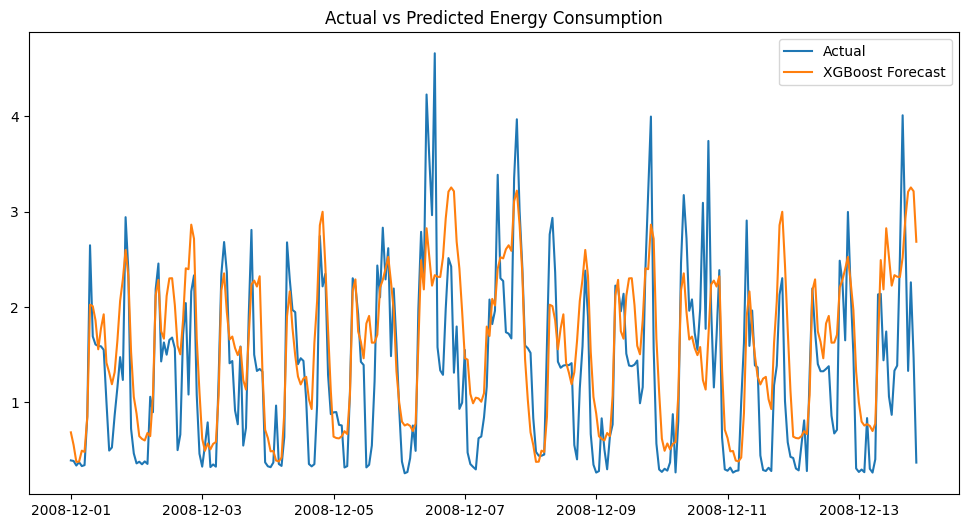

In [21]:
plt.figure(figsize=(12,6))

plt.plot(test.index, y_test, label='Actual')
plt.plot(test.index, forecast_xgb, label='XGBoost Forecast')

plt.legend()
plt.title("Actual vs Predicted Energy Consumption")
plt.show()